<a href="https://colab.research.google.com/github/hoanganh1105/ai-ambulance-coordinator/blob/main/notebooks/Main_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cài đặt

Clone thư mục từ github, cài đặt thư viện.

In [1]:
!git clone https://github.com/hoanganh1105/ai-ambulance-coordinator.git
%cd ai-ambulance-coordinator
!pip install -r requirements.txt

Cloning into 'ai-ambulance-coordinator'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 214 (delta 0), reused 0 (delta 0), pack-reused 212 (from 1)
Receiving objects: 100% (214/214), 3.50 MiB | 3.50 MiB/s, done.
Resolving deltas: 100% (92/92), done.
/content/ai-ambulance-coordinator
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.5/325.5 kB 6.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 8.7 MB/s eta 0:00:00
  Created wheel for pyDatalog: filename=pydatalog-0.17.4-py2.py3-none-any.whl size=74278 sha256=1784b71bb42b288f74cddca904d6293a1a2fb1dd44ff34601c08085f7ccd5996
  Stored in directory: /root/.cache/pip/wheels/3d/86/49/61fd7f650165a5795f4b61720e1aeb2875f7e3f6d09de485be
Successfully built pyDatalog


Tải dataset để train các mô hình.

In [2]:
import kagglehub
disease_classifier_train_dataset = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset", path="Final_Augmented_dataset_Diseases_and_Symptoms.csv")
print("Path to disease dataset:", disease_classifier_train_dataset)
traffic_estimator_train_dataset = kagglehub.dataset_download("guriya79/understanding-delhi-traffic-patterns", path="delhi_traffic_features.csv")
print("Path to traffic dataset:", traffic_estimator_train_dataset)

100%|██████████| 2.81M/2.81M [00:00<00:00, 139MB/s]

Extracting zip of Final_Augmented_dataset_Diseases_and_Symptoms.csv...


Path to disease dataset: /root/.cache/kagglehub/datasets/dhivyeshrk/diseases-and-symptoms-dataset/versions/1/Final_Augmented_dataset_Diseases_and_Symptoms.csv


100%|██████████| 333k/333k [00:00<00:00, 65.6MB/s]

Path to traffic dataset: /root/.cache/kagglehub/datasets/guriya79/understanding-delhi-traffic-patterns/versions/1/delhi_traffic_features.csv


## Khởi tạo mô hình

In [3]:
from modules.core.disease_classifier import *
from modules.core.map_router import *
from modules.core.patient_prioritizer import *
from modules.core.traffic_estimator import *

route_planner = MapRouter()
traffic_estimator = TrafficEstimator()
disease_classifier = DiseaseClassifier()
patient_prioritizer = PatientPrioritizer()

print("=== Training traffic_estimator from dataset ===")
traffic_estimator.train(traffic_estimator_train_dataset)
print("\n=== Training disease_classifier from dataset ===")
disease_classifier.train(disease_classifier_train_dataset)
print("\n=== Loading knowledgebase for patient_prioritizer ===")
patient_prioritizer.load_knowledge_base("features/knowledgebase.txt")

print("\nDone ✅.")

=== Training traffic_estimator from dataset ===
Huấn luyện simpleBayesianNetwork hoàn tất!

=== Training disease_classifier from dataset ===
Đang tải dữ liệu từ /root/.cache/kagglehub/datasets/dhivyeshrk/diseases-and-symptoms-dataset/versions/1/Final_Augmented_dataset_Diseases_and_Symptoms.csv...
Đang chuyển đổi sang Sparse Matrix để tăng tốc...
Đang huấn luyện mô hình simpleClassifierModel...
[HOÀN TẤT] Huấn luyện thành công!

=== Loading knowledgebase for patient_prioritizer ===

Done ✅.


## Cấu hình môi trường

Cấu hình dùng để dự báo tình trạng giao thông. Có thể chỉnh sửa theo gợi ý:

In [4]:
time_of_day = "Night"           # "Morning Peak" / "Afternoon" / "Evening Peak" / "Night"
day_of_week = "Weekday"         # "Weekday" / "Weekend"
weather_condition = "Rain"      # "Clear" / "Rain" / "Fog" / "Heatwave"

## Xử lý chính

Dự báo mức độ kẹt xe bằng `traffic_estimator` và cập nhật trọng số cho các cạnh theo công thức `weight = length * (1 + alpha * jam_level)` để tiến hành tìm đường đi ngắn nhất ở các bước sau.

In [5]:
def density_level_func(data):
  road_type = data.get("highway")
  jam_level = traffic_estimator.estimate_traffic_density_level(time_of_day,
                                                               day_of_week,
                                                               weather_condition,
                                                               road_type)
  return jam_level

def weight_func(data, alpha = 0.5):
  length = data.get("length")
  jam_level = data.get("density_level")
  return length * (1 + alpha * jam_level)

route_planner.add_edges_attribute("density_level", density_level_func)
route_planner.add_edges_attribute("weight", weight_func)

Xử lý các yêu cầu xe cứu thương từ các bệnh nhân: hệ thống sẽ ưu tiên những bệnh nhân có triệu chứng nghiêm trọng nhất, sau đó là các bệnh nhân có bệnh được dự đoán nghiêm trọng nhất và cuối cùng là ưu tiên bệnh nhân gần nhất.

In [6]:
def process_patients_requests(ambulance_coord: tuple[float, float], patients: list[Patient]):
  if not patients:
    print("Không có bệnh nhân để xử lý.")
    return []

  # Dự đoán bệnh của bệnh nhân
  for p in patients:
    p.predicted_disease = disease_classifier.predict(p.symptoms)

  # Danh sách các bệnh nhân được ưu tiên nhất dựa trên triệu chứng và bệnh
  most_prior_patients = patient_prioritizer.get_most_prioritized_patients(patients)

  # Tìm đường đi tới các bệnh nhân đó
  routes = [route_planner.optimal_path(ambulance_coord, p.position) for p in most_prior_patients]

  # Ưu tiên bệnh nhân gần nhất
  nearest = min(routes, key=lambda x: x[1])
  chosen_patient = most_prior_patients[routes.index(nearest)]
  path = nearest[0]

  # Show kết quả
  print("\n=== Kết quả ===")
  print("\nMức độ kẹt xe từ 0 (xanh lá) đến 3 (đỏ)")
  route_planner.show_map(show_density=True)
  print(f"\nVị trí xe cứu thương: {ambulance_coord}")
  from tabulate import tabulate
  headers = ["ID", "Vị trí", "Triệu chứng", "Chẩn đoán", "Được chọn"]
  rows = [[p.id, p.position, ", ".join(p.symptoms), p.predicted_disease, '*' if p is chosen_patient else ''] for p in patients]
  print(tabulate(rows, headers=headers, tablefmt="grid"))
  route_planner.show_map(route=path, org=ambulance_coord, dests=[p.position for p in patients])
  print(f"\nĐường đi: {path}")

  return path

## Giao diện tương tác

Thực hiện theo các bước sau:

1. Chọn vị trí xe cứu thương
2. Thêm một số lượng bệnh nhân tuỳ ý bằng cách lặp lại cách bước:
  - Chọn vị trí bệnh nhân
  - Liệt kê các triệu chứng
  - Nhấn "Thêm bệnh nhân"
3. Nhấn "Kết thúc và trả kết quả"
    

Nearest nodes: source=301037185, target=6385220675

=== Kết quả ===

Mức độ kẹt xe từ 0 (xanh lá) đến 3 (đỏ)


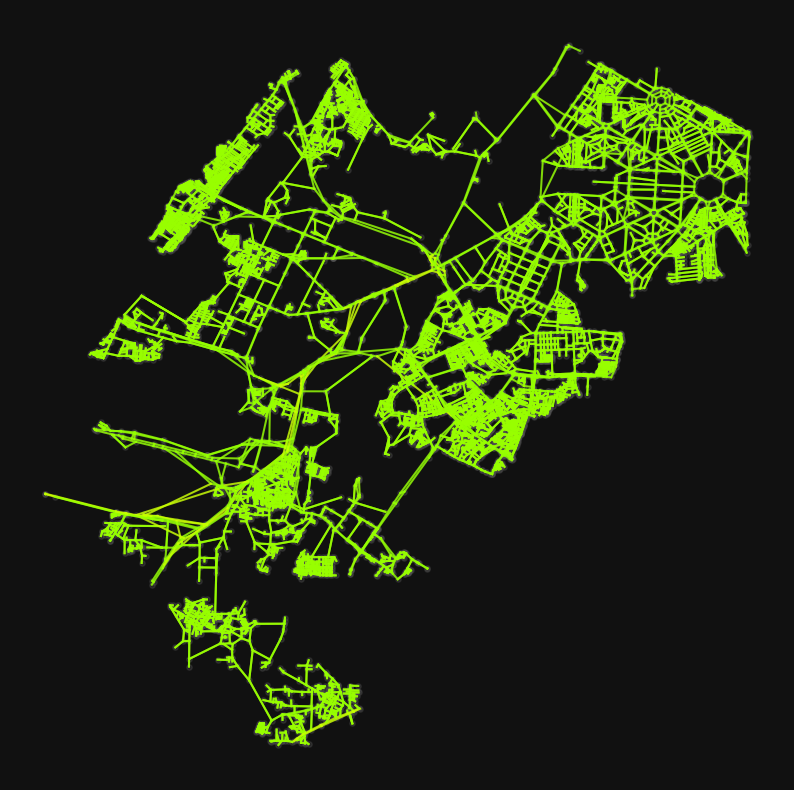


Vị trí xe cứu thương: (28.6011015875013, 77.2053909301758)
+------+-----------------------------------------+-----------------------------------------------------+----------------------------------------------+-------------+
|   ID | Vị trí                                  | Triệu chứng                                         | Chẩn đoán                                    | Được chọn   |
+======+=========================================+=====================================================+==============================================+=============+
|    1 | (28.580300971796593, 77.09896087646486) | frontal headache, dizziness                         | benign paroxysmal positional vertical (bppv) |             |
+------+-----------------------------------------+-----------------------------------------------------+----------------------------------------------+-------------+
|    2 | (28.63033607110889, 77.14393615722658)  | sore throat, hoarse voice, difficulty breathing     | head 

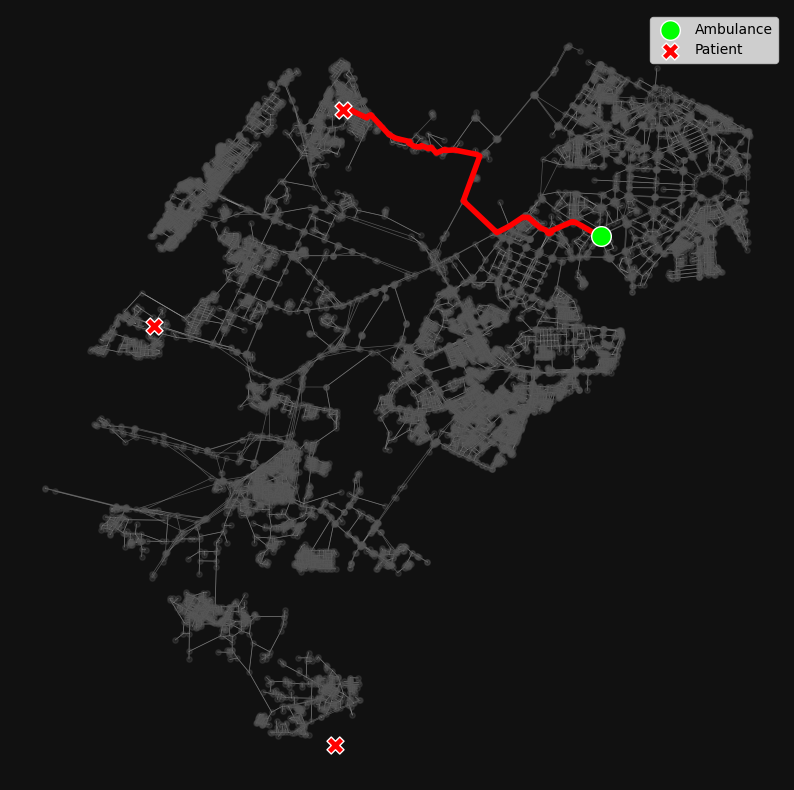


Đường đi: [(28.6012475, 77.2054475), (28.6008952, 77.205303), (28.6008042, 77.2050656), (28.6008201, 77.2048783), (28.600924, 77.2046897), (28.6013181, 77.2045946), (28.6019854, 77.2035604), (28.6028078, 77.2021193), (28.6035854, 77.2007446), (28.6043971, 77.1991758), (28.6043167, 77.1988536), (28.6044645, 77.1985455), (28.6030722, 77.1953097), (28.6029979, 77.1951365), (28.6023719, 77.1936388), (28.6021506, 77.1936958), (28.6018622, 77.1935752), (28.6017, 77.1930735), (28.6018535, 77.1927646), (28.6022356, 77.1926432), (28.6025369, 77.1922883), (28.6030442, 77.1910488), (28.6030931, 77.19098), (28.6033762, 77.1906171), (28.6038923, 77.1899735), (28.6040941, 77.1897194), (28.6045849, 77.1891571), (28.6052261, 77.1884224), (28.6054428, 77.1881745), (28.6054773, 77.188134), (28.6054492, 77.1869988), (28.6055279, 77.1868539), (28.6034408, 77.1836422), (28.6034019, 77.1835655), (28.60212, 77.1810366), (28.6019775, 77.180755), (28.6019323, 77.1806772), (28.6019923, 77.1806192), (28.6021833

In [7]:
from modules.ui.dispatch_ui import *
create_dispatch_interface(route_planner.place, list(disease_classifier.symptoms_vocab), process_patients_requests)

In [8]:
# %cd ..
# !rm -rfv ai-ambulance-coordinator